In [25]:
import numpy as np
import matplotlib.pyplot as plt

### Estructura de la Red
*   **Entradas ($X$):** 3 entradas (representando los 3 bits).
*   **Salidas ($y$):** 2 neuronas.
    *   Neurona 1: Aprenderá la lógica **AND**.
    *   Neurona 2: Aprenderá la lógica **OR**.
*   **Bias ($b$):** Un valor de sesgo independiente para cada neurona de salida.

El sustento matemático es el mismo que se dió en el notebook con 2 bits de entrada

In [26]:
#Función de activación escalon
def step_function(x):
    return np.where(x >= 0, 1, 0)

#Función de predicción del perceptrón
def perceptron_predict(X, weights):
    return step_function(np.dot(X, weights[1:]) + weights[0])

# Algoritmo del Perceptrón
def perceptron_train(X, y, learning_rate=0.1, epochs=10):
    n_features = X.shape[1] #Número de características 
    n_outputs = y.shape[1] # Número de neuronas de salida
    
    # Inicializar matriz de pesos (n_features + 1 filas, n_outputs columnas)
    weights = np.random.rand(n_features + 1, n_outputs)
    errors = []

    for _ in range(epochs):
        total_error = 0
        for xi, target in zip(X, y):
            #Predicción
            output = perceptron_predict(xi, weights)
            
            # Calculo error
            error = target - output
            total_error += np.sum(np.abs(error)) # Suma de errores de todas las salidas

            # Actualizar pesos
            # Bias: se actualiza con learning_rate * error
            weights[0] += learning_rate * error
            # Pesos de entradas (filas 1 a n): producto externo de entrada x error
            weights[1:] += learning_rate * np.outer(xi, error)
            
        errors.append(total_error)
    return weights, errors

### Definición del Dataset

Definimos las 8 posibles combinaciones de 3 bits ($2^3=8$) y sus salidas correspondientes para las compuertas:
1.  **AND (3 inputs):** Salida es 1 solo si las 3 entradas son 1.
2.  **OR (3 inputs):** Salida es 1 si almenos una entrada es 1.

In [27]:
# ---Preparación de Datos (3 Entradas, 2 Salidas) ---
# Entradas (3 bits)
X = np.array([
    [0, 0, 0], [0, 0, 1],
    [0, 1, 0], [0, 1, 1],
    [1, 0, 0], [1, 0, 1],
    [1, 1, 0], [1, 1, 1]
])

# Salidas esperadas:
# Columna 0: AND
# Columna 1: OR
y = np.array([
    [0, 0], # 000 -> AND=0, OR=0
    [0, 1], # 001 -> AND=0, OR=1
    [0, 1], 
    [0, 1], 
    [0, 1], 
    [0, 1], 
    [0, 1], 
    [1, 1]  
])

print("Entradas X:\n", X)
print("\nSalidas Esperadas Y (Col0=AND, Col1=OR):\n", y)

Entradas X:
 [[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]

Salidas Esperadas Y (Col0=AND, Col1=OR):
 [[0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 1]]


In [28]:
# --- Entrenamiento de la Red ---

weights, errors = perceptron_train(X, y, learning_rate=0.1, epochs=30)

print("Entrenamiento completado.")
print("Matriz de Pesos Finales:\n", weights)

# print(f"Pesos de la neurona AND{weights[:,0]}")
# print(f"Pesos de la neurona OR{weights[:,1]}")

Entrenamiento completado.
Matriz de Pesos Finales:
 [[-0.43872292 -0.09144476]
 [ 0.24636252  0.12966498]
 [ 0.11057162  0.73962706]
 [ 0.15584041  0.84589202]]


In [29]:
# --- Validación / Predicciones ---
print("\n--- Validación del Modelo ---")
print(f"{'Entrada (X)':<15} | {'Esperado (AND/OR)':<18} | {'Predicción (AND/OR)':<20} | {'¿Correcto?'}")
print("-" * 70)

aciertos = 0
for i, xi in enumerate(X):
    prediction = perceptron_predict(xi, weights)
    target = y[i]
    
    es_correcto = np.array_equal(prediction, target)
    if es_correcto: aciertos += 1
    
    print(f"{str(xi):<15} | {str(target):<18} | {str(prediction):<20} | {'Si' if es_correcto else 'No'}")

print("-" * 70)
print(f"Precisión Total: {aciertos}/{len(X)} ({(aciertos/len(X))*100:.1f}%)")


--- Validación del Modelo ---
Entrada (X)     | Esperado (AND/OR)  | Predicción (AND/OR)  | ¿Correcto?
----------------------------------------------------------------------
[0 0 0]         | [0 0]              | [0 0]                | Si
[0 0 1]         | [0 1]              | [0 1]                | Si
[0 1 0]         | [0 1]              | [0 1]                | Si
[0 1 1]         | [0 1]              | [0 1]                | Si
[1 0 0]         | [0 1]              | [0 1]                | Si
[1 0 1]         | [0 1]              | [0 1]                | Si
[1 1 0]         | [0 1]              | [0 1]                | Si
[1 1 1]         | [1 1]              | [1 1]                | Si
----------------------------------------------------------------------
Precisión Total: 8/8 (100.0%)


### Visualización de la Convergencia

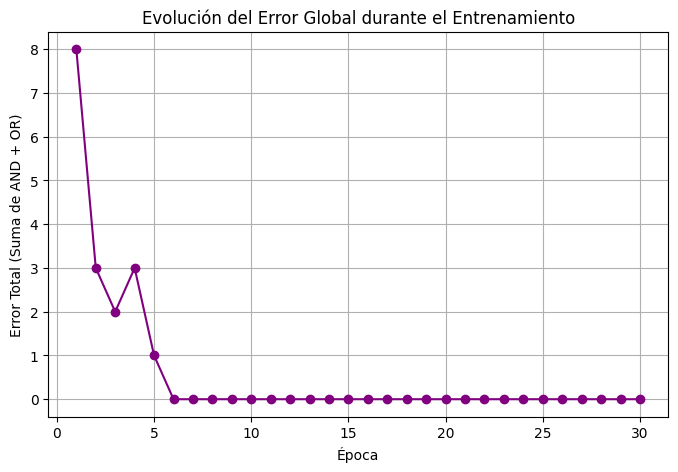

In [30]:
# --- Gráfica de Error Global ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errors) + 1), errors, marker='o', color='purple')
plt.xlabel('Época')
plt.ylabel('Error Total (Suma de AND + OR)')
plt.title('Evolución del Error Global durante el Entrenamiento')
plt.grid(True)
plt.show()

### Visualización 3D: Planos de Decisión

Dado que tenemos 3 entradas ($x_1, x_2, x_3$), el espacio de entrada es tridimensional.
El Perceptrón aprende un **Plano de Separación** lineal definido por la ecuación general:

$$ w_1 \cdot x_1 + w_2 \cdot x_2 + w_3 \cdot x_3 + b = 0 $$

Para graficar este plano en el espacio 3D, despejamos para $x_3$ (que actuará como el eje Z vertical):

$$ x_3 = - \frac{w_1 \cdot x_1 + w_2 \cdot x_2 + b}{w_3} $$

*   **Puntos Rojos/Azules:** Datos de entrenamiento.
*   **Plano Cian:** Frontera de decisión aprendida. Los puntos a un lado del plano se clasifican como 0 y al otro como 1.

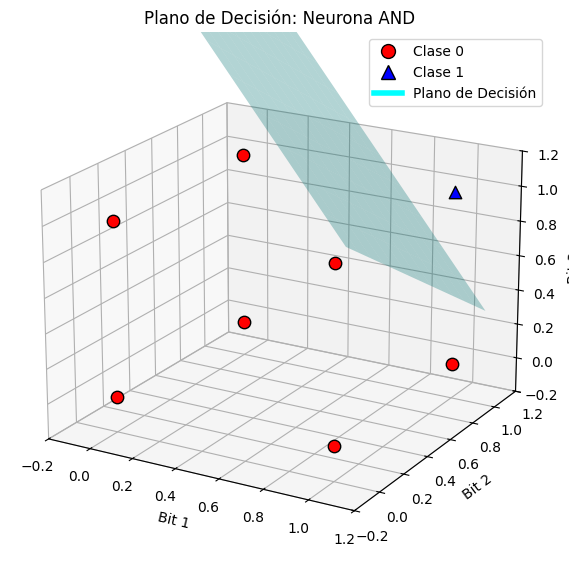

In [31]:
# Visualización 3D de Planos de Decisión ---

# SOLO EN VSCODE (NO FUNCIONA EN COLAB)
#   Instalar ipympl (pip install ipympl) para gráficos interactivos en Jupyter Notebook
#   Descomentar la linea de abajo, reiniciar y correr el notebook para poder rotar graficas con el mouse
# %matplotlib widget
from matplotlib.lines import Line2D

def plot_decision_boundary_3d(X, y_target, single_weights, title, ax, elev=20, azim=-60):
    # Graficar puntos de datos
    for i, xi in enumerate(X):
        # y_target[i] es escalar (0 o 1) para esta neurona específica
        color = 'red' if y_target[i] == 0 else 'blue'
        marker = 'o' if y_target[i] == 0 else '^'
        
        ax.scatter(xi[0], xi[1], xi[2], c=color, marker=marker, s=80, edgecolors='k')

    
    # Plano de decisión: w1*x1 + w2*x2 + w3*x3 + w0 = 0 -> x3 = -(w1*x1 + w2*x2 + w0)/w3
    # single_weights es vector (4,): [bias, w1, w2, w3]
    w0, w1, w2, w3 = single_weights[0], single_weights[1], single_weights[2], single_weights[3]
    
    xx, yy = np.meshgrid(np.arange(-0.1, 1.2, 0.1), np.arange(-0.1, 1.2, 0.1))
    
    if abs(w3) > 1e-5:
        z = (-w1 * xx - w2 * yy - w0) / w3
        ax.plot_surface(xx, yy, z, alpha=0.3, color='cyan')
    
    ax.set_xlabel('Bit 1')
    ax.set_ylabel('Bit 2')
    ax.set_zlabel('Bit 3')
    ax.set_title(title)
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_zlim(-0.2, 1.2)
    
    # Rotación de la cámara
    ax.view_init(elev=elev, azim=azim)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Clase 0', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='Clase 1', markersize=10, markeredgecolor='k'),
        Line2D([0], [0], color='cyan', lw=4, label='Plano de Decisión') # Representación simbólica del plano
    ]
    ax.legend(handles=legend_elements)

# Definir ángulos de rotación compartidos
ELEVACION = 20
ROTACION = -60

# --- GRÁFICA 1: Neurona AND ---
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
weights_and = weights[:, 0] # Columna 0
plot_decision_boundary_3d(X, y[:, 0], weights_and, "Plano de Decisión: Neurona AND", ax1, ELEVACION, ROTACION)
plt.show()

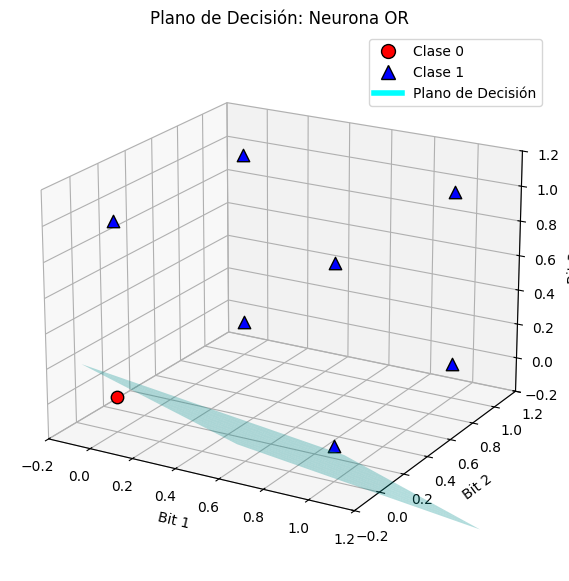

In [32]:
# --- GRÁFICA 2: Neurona OR ---
fig2 = plt.figure(figsize=(10, 7))
ax2 = fig2.add_subplot(111, projection='3d')
weights_or = weights[:, 1]  # Columna 1
plot_decision_boundary_3d(X, y[:, 1], weights_or, "Plano de Decisión: Neurona OR", ax2, ELEVACION, ROTACION)
plt.show()